In [1]:
try:
    # Running inside Google Colab → use !pip
    import google.colab
    in_google_colab = True
    print("Running in Colab → installing packages...")
    !pip install -q bertopic
    !pip install -q tweet-preprocessor
    !pip install -q spacy-entity-linker
    !pip install -q emoji
    !pip install sentence-transformers scikit-learn
    !pip install "transformers>=4.40.0" sentencepiece accelerate torch
except ImportError:
    # Not running in Colab → do nothing
    in_google_colab = False
    pass

Running in Colab → installing packages...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 7.9 MB/s eta 0:00:00


In [2]:
# from pathlib import Path
# import pandas as pd

# dataset_name = "Labeled_Datasets/Ecuador"  # folder path
# file_name = "Ecuador_part_4.gzip.parquet"  # file name

# # Google Colab
# if in_google_colab:
#     from google.colab import drive
#     drive.mount('/content/drive')
#     dataset_path = Path("/content/drive/Shareddrives/KeyBoostAuthor") / dataset_name / file_name
#     print("Running inside Colab. Loading from Google Drive...")

# # Cluster\Local
# else:
#     dataset_path = Path("../data") / dataset_name / file_name
#     print(f"Running on local/cluster.\nLoading data from: {dataset_path}")


# # Load the parquet file
# df = pd.read_parquet(dataset_path)

# # for testing



from pathlib import Path
import pandas as pd

dataset_name = "Labeled_Datasets/Ecuador"  # folder path

dfs = []

# Google Colab
if in_google_colab:
    from google.colab import drive
    drive.mount('/content/drive')
    base_path = Path("/content/drive/Shareddrives/KeyBoostAuthor") / dataset_name
    print("Running inside Colab. Loading from Google Drive...")

# Cluster / Local
else:
    base_path = Path("../data") / dataset_name
    print(f"Running on local/cluster.\nLoading data from: {base_path}")

for i in range(1, 31):
    file_name = f"Ecuador_part_{i}.gzip.parquet"
    file_path = base_path / file_name

    print(f"Loading: {file_path}")
    df_part = pd.read_parquet(file_path)
    dfs.append(df_part)

df = pd.concat(dfs, ignore_index=True)

print("Done! Combined dataframe shape:", df.shape)


Mounted at /content/drive
Running inside Colab. Loading from Google Drive...
Loading: /content/drive/Shareddrives/KeyBoostAuthor/Labeled_Datasets/Ecuador/Ecuador_part_1.gzip.parquet
Loading: /content/drive/Shareddrives/KeyBoostAuthor/Labeled_Datasets/Ecuador/Ecuador_part_2.gzip.parquet
Loading: /content/drive/Shareddrives/KeyBoostAuthor/Labeled_Datasets/Ecuador/Ecuador_part_3.gzip.parquet
Loading: /content/drive/Shareddrives/KeyBoostAuthor/Labeled_Datasets/Ecuador/Ecuador_part_4.gzip.parquet
Loading: /content/drive/Shareddrives/KeyBoostAuthor/Labeled_Datasets/Ecuador/Ecuador_part_5.gzip.parquet
Loading: /content/drive/Shareddrives/KeyBoostAuthor/Labeled_Datasets/Ecuador/Ecuador_part_6.gzip.parquet
Loading: /content/drive/Shareddrives/KeyBoostAuthor/Labeled_Datasets/Ecuador/Ecuador_part_7.gzip.parquet
Loading: /content/drive/Shareddrives/KeyBoostAuthor/Labeled_Datasets/Ecuador/Ecuador_part_8.gzip.parquet
Loading: /content/drive/Shareddrives/KeyBoostAuthor/Labeled_Datasets/Ecuador/Ecuado

In [4]:
df.columns

Index(['postid', 'post_text', 'application_name', 'post_language',
       'in_reply_to_postid', 'in_reply_to_accountid', 'post_time', 'accountid',
       'account_profile_description', 'follower_count', 'following_count',
       'account_creation_date', 'is_repost', 'reposted_accountid',
       'reposted_postid', 'hashtags', 'urls', 'account_mentions',
       'is_control'],
      dtype='object')

In [5]:
df["is_control"].value_counts()


,count
is_control,
True,770289
False,700240


In [89]:
df.post_text.iloc[0]

'Vamos a cambiar la forma de hacer comunicación corporativa'

In [6]:
unique_control_users = df.loc[df["is_control"] == True, "accountid"].nunique()
print("is_control:TRUE",unique_control_users)


is_control:TRUE 21138


In [7]:
unique_control_users = df.loc[df["is_control"] == False, "accountid"].nunique()
print("is_control:False",unique_control_users)


is_control:False 787


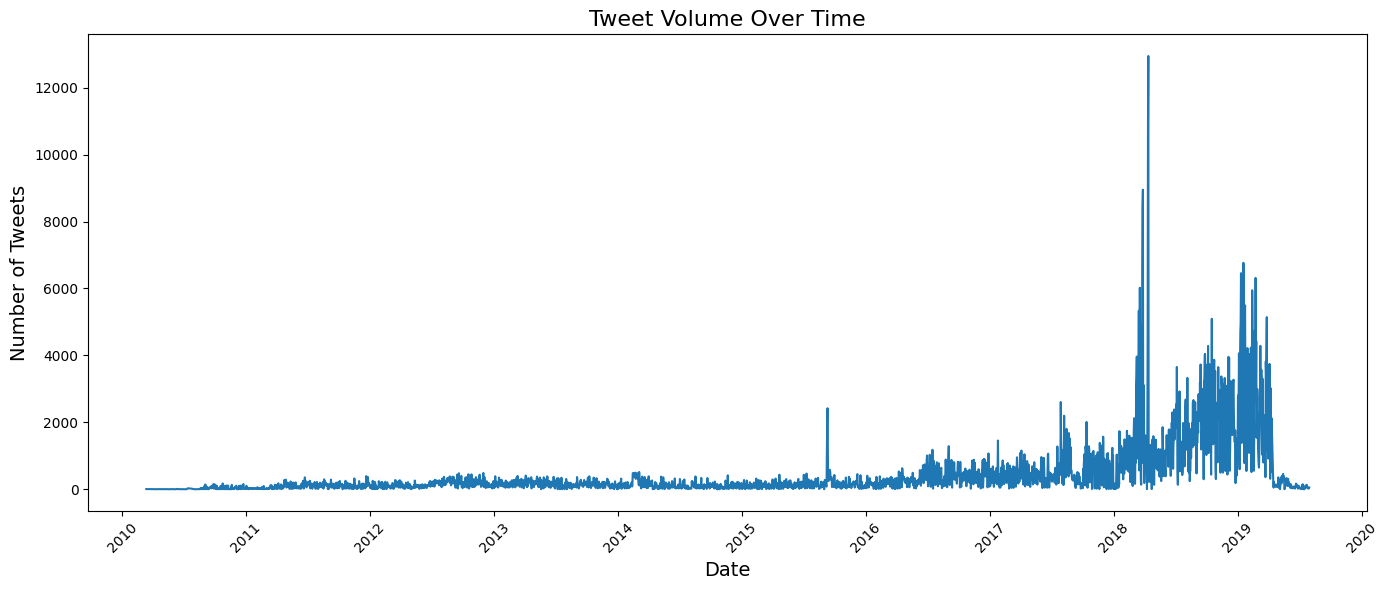

In [8]:
import matplotlib.pyplot as plt

# -----------------------------
# 2. Convert post_time to datetime
# -----------------------------
df["post_time"] = pd.to_datetime(df["post_time"], errors="coerce")

df = df.dropna(subset=["post_time"])

# -----------------------------
# 3. Count tweets per day
# -----------------------------
tweets_per_day = df.groupby(df["post_time"].dt.date).size()

# -----------------------------
# 4. Plot
# -----------------------------
plt.figure(figsize=(14, 6))
plt.plot(tweets_per_day.index, tweets_per_day.values)
plt.title("Tweet Volume Over Time", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Number of Tweets", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


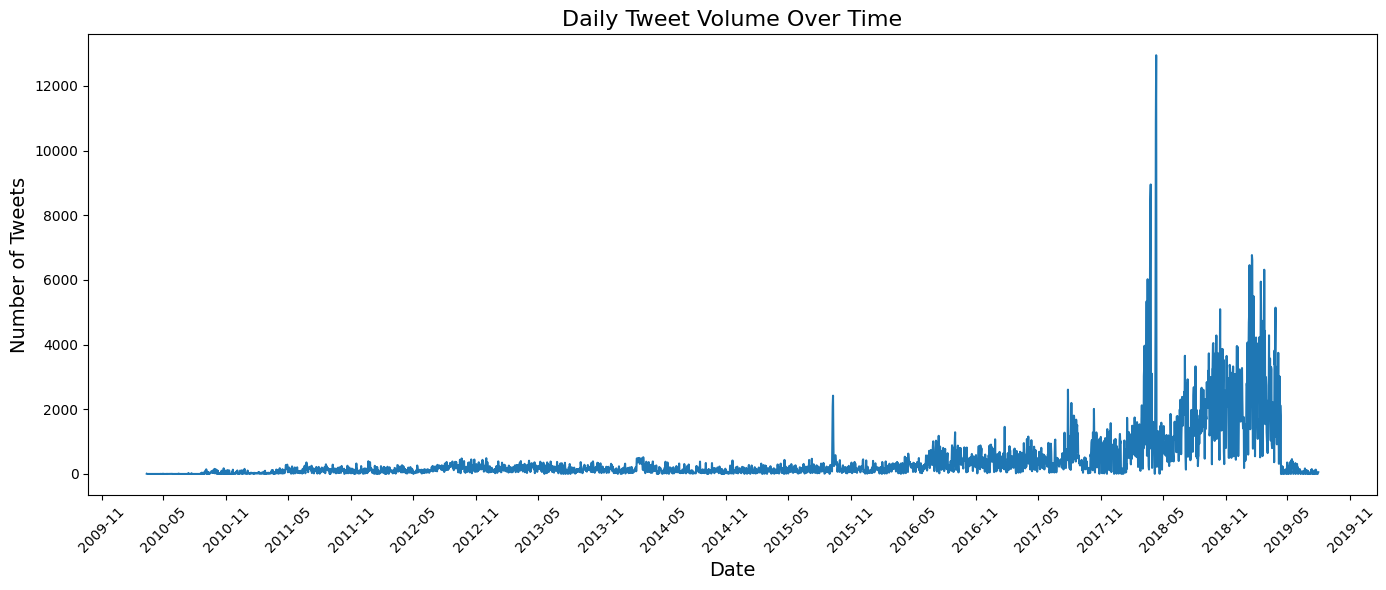

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# -----------------------------
# 1. Convert post_time to datetime
# -----------------------------
df["post_time"] = pd.to_datetime(df["post_time"], errors="coerce")
df = df.dropna(subset=["post_time"])

# -----------------------------
# 2. Count tweets per day (daily resolution)
# -----------------------------
tweets_per_day = (
    df
    .set_index("post_time")
    .resample("D")
    .size()
)

# -----------------------------
# 3. Plot daily volume with 6-month ticks
# -----------------------------
plt.figure(figsize=(14, 6))
plt.plot(tweets_per_day.index, tweets_per_day.values)

plt.title("Daily Tweet Volume Over Time", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Number of Tweets", fontsize=14)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#Using Pelt

In [9]:
!pip install ruptures


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.4 MB/s eta 0:00:00


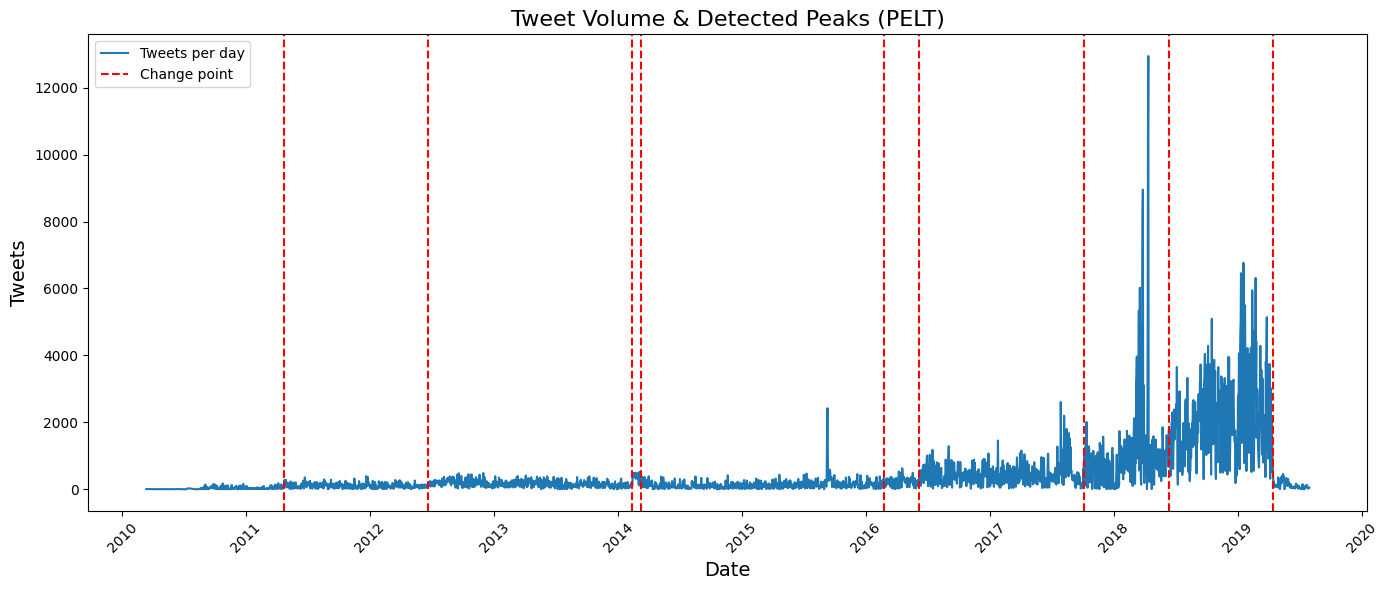

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import ruptures as rpt

# -----------------------------------------------------
# Load data
# -----------------------------------------------------
df["post_time"] = pd.to_datetime(df["post_time"], errors="coerce")
df = df.dropna(subset=["post_time"])

# -----------------------------------------------------
# Aggregate tweets per day
# -----------------------------------------------------
tweets_per_day = df.groupby(df["post_time"].dt.date).size()
ts_values = tweets_per_day.values

# -----------------------------------------------------
# Apply PELT
# -----------------------------------------------------
model = "rbf"  # Detects changes in mean/variance
algo = rpt.Pelt(model=model).fit(ts_values)

result = algo.predict(pen=10)

# -----------------------------------------------------
# Plot results
# -----------------------------------------------------
plt.figure(figsize=(14,6))
plt.plot(tweets_per_day.index, ts_values, label="Tweets per day")
for cp in result[:-1]:  # ignore last change point (end of series)
    plt.axvline(tweets_per_day.index[cp], color="red", linestyle="--", label="Change point" if cp == result[0] else "")

plt.title("Tweet Volume & Detected Peaks (PELT)", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Tweets", fontsize=14)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [73]:
import pandas as pd
import numpy as np
import ruptures as rpt

# -----------------------------------------------------
# Prepare data
# -----------------------------------------------------
df["post_time"] = pd.to_datetime(df["post_time"], errors="coerce")
df = df.dropna(subset=["post_time"])

# Tweets per day
tweets_per_day = df.groupby(df["post_time"].dt.date).size()
ts = tweets_per_day.values
dates = pd.to_datetime(tweets_per_day.index)

# # -----------------------------------------------------
# # 1. Detect change points (peaks) using PELT
# # -----------------------------------------------------
algo = rpt.Pelt(model="rbf").fit(ts)
change_points = algo.predict(pen=10)  # includes end of series

# Real change point dates
cp_dates = [dates[i] for i in change_points[:-1]]

# -----------------------------------------------------
# 2. Compute derivative of tweet volume
# -----------------------------------------------------
tweets_derivative = tweets_per_day.diff().fillna(0)

# Rolling smoother
rolling_derivative = tweets_per_day.rolling(3, center=True).mean().diff().fillna(0)

# -----------------------------------------------------
# 3. For each post → classify before/after peak + derivative
# -----------------------------------------------------
results = []

for idx, row in df.iterrows():
    t = row["post_time"].date()

    # Get derivative (if day missing → 0)
    deriv = tweets_derivative.get(t, 0)
    r_deriv = rolling_derivative.get(t, 0)

    # Find nearest change point
    if len(cp_dates) > 0:
        diffs = [(cp - pd.Timestamp(t)).days for cp in cp_dates]
        closest_idx = np.argmin(np.abs(diffs))
        closest_cp = cp_dates[closest_idx]
        diff_days = diffs[closest_idx]

        if diff_days > 0:
            relation = "before_peak"
        elif diff_days < 0:
            relation = "after_peak"
        else:
            relation = "at_peak"
    else:
        relation = "no_peak_detected"

    results.append({
        "post_id": row.get("postid", idx),
        "post_time": row["post_time"],
        "derivative": deriv,
        "rolling_derivative": r_deriv,
        "peak_relation": relation,
        "nearest_peak": closest_cp if len(cp_dates)>0 else None,
        "delta_days_to_peak": diff_days if len(cp_dates)>0 else None
    })

post_analysis_df = pd.DataFrame(results)


In [75]:
post_analysis_df = post_analysis_df.merge(
    df[["postid","accountid", "is_control"]],
    left_on="post_id",
    right_on="postid",
    how="left"
)


In [77]:
post_analysis_df

,post_id,post_time,derivative,rolling_derivative,peak_relation,nearest_peak,delta_days_to_peak,postid_x,accountid_x,is_control_x,postid_y,accountid_y,is_control_y
0,0bafe020a260495bee38b98fde83668d924454019b,2010-03-13 02:52:00,0.0,0.0,before_peak,2011-04-23,406,0bafe020a260495bee38b98fde83668d924454019b,22de67d991b31493165b9270f7d8b5b4ce712d5fc8,False,0bafe020a260495bee38b98fde83668d924454019b,22de67d991b31493165b9270f7d8b5b4ce712d5fc8,False
1,608fba51f2460c7f1ca527dfc48de2bc858d4ad201,2010-03-13 03:08:00,0.0,0.0,before_peak,2011-04-23,406,608fba51f2460c7f1ca527dfc48de2bc858d4ad201,22de67d991b31493165b9270f7d8b5b4ce712d5fc8,False,608fba51f2460c7f1ca527dfc48de2bc858d4ad201,22de67d991b31493165b9270f7d8b5b4ce712d5fc8,False
2,514b2c38b26e240cac85382be74ed7d61a02468ac1,2010-03-13 15:26:00,0.0,0.0,before_peak,2011-04-23,406,514b2c38b26e240cac85382be74ed7d61a02468ac1,2c6c0ef5f445760177b016e33b36809bde3c7ac241,False,514b2c38b26e240cac85382be74ed7d61a02468ac1,2c6c0ef5f445760177b016e33b36809bde3c7ac241,False
3,e82a816068e88387d19430348f0420b040e0d11b4e,2010-03-13 15:32:00,0.0,0.0,before_peak,2011-04-23,406,e82a816068e88387d19430348f0420b040e0d11b4e,2c6c0ef5f445760177b016e33b36809bde3c7ac241,False,e82a816068e88387d19430348f0420b040e0d11b4e,2c6c0ef5f445760177b016e33b36809bde3c7ac241,False
4,13ed6aaeec4fffaf840f1c42ff88f5ab2cb324be64,2010-03-13 15:35:00,0.0,0.0,before_peak,2011-04-23,406,13ed6aaeec4fffaf840f1c42ff88f5ab2cb324be64,2c6c0ef5f445760177b016e33b36809bde3c7ac241,False,13ed6aaeec4fffaf840f1c42ff88f5ab2cb324be64,2c6c0ef5f445760177b016e33b36809bde3c7ac241,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1470866,7d4943612fa49e3383aaf35e574c57100440f05c19,2019-07-30 23:59:36,30.0,0.0,after_peak,2019-04-15,-106,7d4943612fa49e3383aaf35e574c57100440f05c19,e7eaeff8e0c28aacd31031fc634cc1931060f7f99b,True,7d4943612fa49e3383aaf35e574c57100440f05c19,e7eaeff8e0c28aacd31031fc634cc1931060f7f99b,True
1470867,9c2a3050ec05d05f083438a6163ce96099e1a88e9d,2019-07-30 23:59:45,30.0,0.0,after_peak,2019-04-15,-106,9c2a3050ec05d05f083438a6163ce96099e1a88e9d,e00dad99e39f6c5816bdc47fedd9a20b3982a8d855,True,9c2a3050ec05d05f083438a6163ce96099e1a88e9d,e00dad99e39f6c5816bdc47fedd9a20b3982a8d855,True
1470868,c3e606bde49d62fd51fbcf381b647f7713af4675dd,2019-07-30 23:59:48,30.0,0.0,after_peak,2019-04-15,-106,c3e606bde49d62fd51fbcf381b647f7713af4675dd,e7eaeff8e0c28aacd31031fc634cc1931060f7f99b,True,c3e606bde49d62fd51fbcf381b647f7713af4675dd,e7eaeff8e0c28aacd31031fc634cc1931060f7f99b,True
1470869,a0dcb2fae5dcc88bc1a543a758e48207ec9c3ee040,2019-07-30 23:59:51,30.0,0.0,after_peak,2019-04-15,-106,a0dcb2fae5dcc88bc1a543a758e48207ec9c3ee040,e7eaeff8e0c28aacd31031fc634cc1931060f7f99b,True,a0dcb2fae5dcc88bc1a543a758e48207ec9c3ee040,e7eaeff8e0c28aacd31031fc634cc1931060f7f99b,True


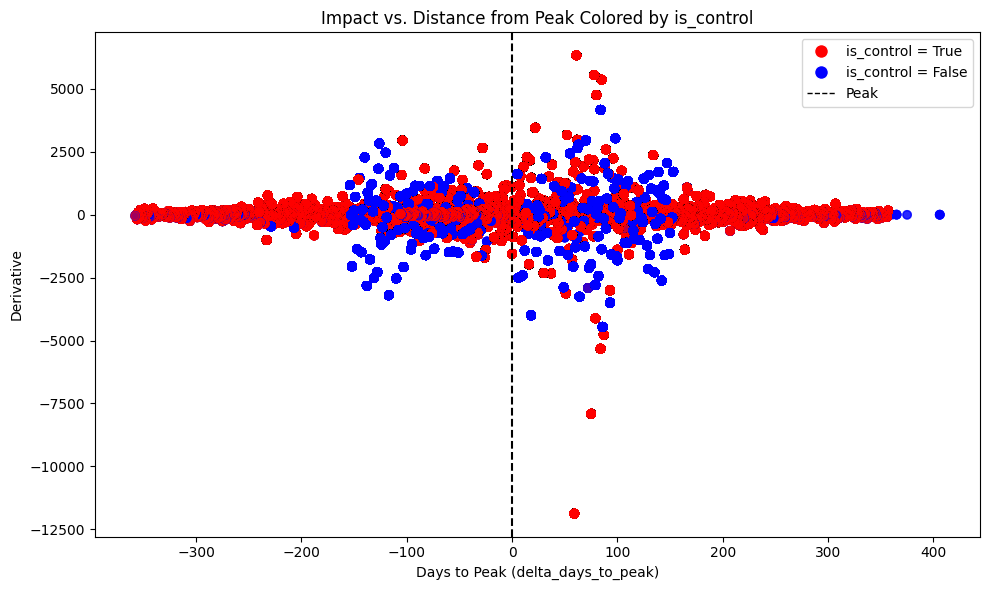

In [78]:
import matplotlib.pyplot as plt

colors = post_analysis_df["is_control_x"].map({True: "red", False: "blue"})

plt.figure(figsize=(10, 6))
plt.scatter(
    post_analysis_df["delta_days_to_peak"],
    post_analysis_df["derivative"],
    c=colors,
    alpha=0.6
)

plt.axvline(0, color="black", linestyle="--", label="Peak")

plt.xlabel("Days to Peak (delta_days_to_peak)")
plt.ylabel("Derivative")
plt.title("Impact vs. Distance from Peak Colored by is_control")

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='is_control = True', markerfacecolor='red', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='is_control = False', markerfacecolor='blue', markersize=10),
    Line2D([0], [0], color='black', lw=1, linestyle='--', label='Peak')
]

plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()


In [80]:
post_analysis_df

,post_id,post_time,derivative,rolling_derivative,peak_relation,nearest_peak,delta_days_to_peak,postid_x,accountid_x,is_control_x,postid_y,accountid_y,is_control_y
0,0bafe020a260495bee38b98fde83668d924454019b,2010-03-13 02:52:00,0.0,0.0,before_peak,2011-04-23,406,0bafe020a260495bee38b98fde83668d924454019b,22de67d991b31493165b9270f7d8b5b4ce712d5fc8,False,0bafe020a260495bee38b98fde83668d924454019b,22de67d991b31493165b9270f7d8b5b4ce712d5fc8,False
1,608fba51f2460c7f1ca527dfc48de2bc858d4ad201,2010-03-13 03:08:00,0.0,0.0,before_peak,2011-04-23,406,608fba51f2460c7f1ca527dfc48de2bc858d4ad201,22de67d991b31493165b9270f7d8b5b4ce712d5fc8,False,608fba51f2460c7f1ca527dfc48de2bc858d4ad201,22de67d991b31493165b9270f7d8b5b4ce712d5fc8,False
2,514b2c38b26e240cac85382be74ed7d61a02468ac1,2010-03-13 15:26:00,0.0,0.0,before_peak,2011-04-23,406,514b2c38b26e240cac85382be74ed7d61a02468ac1,2c6c0ef5f445760177b016e33b36809bde3c7ac241,False,514b2c38b26e240cac85382be74ed7d61a02468ac1,2c6c0ef5f445760177b016e33b36809bde3c7ac241,False
3,e82a816068e88387d19430348f0420b040e0d11b4e,2010-03-13 15:32:00,0.0,0.0,before_peak,2011-04-23,406,e82a816068e88387d19430348f0420b040e0d11b4e,2c6c0ef5f445760177b016e33b36809bde3c7ac241,False,e82a816068e88387d19430348f0420b040e0d11b4e,2c6c0ef5f445760177b016e33b36809bde3c7ac241,False
4,13ed6aaeec4fffaf840f1c42ff88f5ab2cb324be64,2010-03-13 15:35:00,0.0,0.0,before_peak,2011-04-23,406,13ed6aaeec4fffaf840f1c42ff88f5ab2cb324be64,2c6c0ef5f445760177b016e33b36809bde3c7ac241,False,13ed6aaeec4fffaf840f1c42ff88f5ab2cb324be64,2c6c0ef5f445760177b016e33b36809bde3c7ac241,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1470866,7d4943612fa49e3383aaf35e574c57100440f05c19,2019-07-30 23:59:36,30.0,0.0,after_peak,2019-04-15,-106,7d4943612fa49e3383aaf35e574c57100440f05c19,e7eaeff8e0c28aacd31031fc634cc1931060f7f99b,True,7d4943612fa49e3383aaf35e574c57100440f05c19,e7eaeff8e0c28aacd31031fc634cc1931060f7f99b,True
1470867,9c2a3050ec05d05f083438a6163ce96099e1a88e9d,2019-07-30 23:59:45,30.0,0.0,after_peak,2019-04-15,-106,9c2a3050ec05d05f083438a6163ce96099e1a88e9d,e00dad99e39f6c5816bdc47fedd9a20b3982a8d855,True,9c2a3050ec05d05f083438a6163ce96099e1a88e9d,e00dad99e39f6c5816bdc47fedd9a20b3982a8d855,True
1470868,c3e606bde49d62fd51fbcf381b647f7713af4675dd,2019-07-30 23:59:48,30.0,0.0,after_peak,2019-04-15,-106,c3e606bde49d62fd51fbcf381b647f7713af4675dd,e7eaeff8e0c28aacd31031fc634cc1931060f7f99b,True,c3e606bde49d62fd51fbcf381b647f7713af4675dd,e7eaeff8e0c28aacd31031fc634cc1931060f7f99b,True
1470869,a0dcb2fae5dcc88bc1a543a758e48207ec9c3ee040,2019-07-30 23:59:51,30.0,0.0,after_peak,2019-04-15,-106,a0dcb2fae5dcc88bc1a543a758e48207ec9c3ee040,e7eaeff8e0c28aacd31031fc634cc1931060f7f99b,True,a0dcb2fae5dcc88bc1a543a758e48207ec9c3ee040,e7eaeff8e0c28aacd31031fc634cc1931060f7f99b,True


In [81]:
user_df = (
    post_analysis_df
    .groupby("accountid_y")
    .agg(
        mean_derivative=("derivative", "mean"),
        mean_abs_derivative=("derivative", lambda x: x.abs().mean()),
        mean_delta_days=("delta_days_to_peak", "mean"),
        n_posts=("post_id", "count"),
        is_control=("is_control_x", "first")
    )
    .reset_index()
)


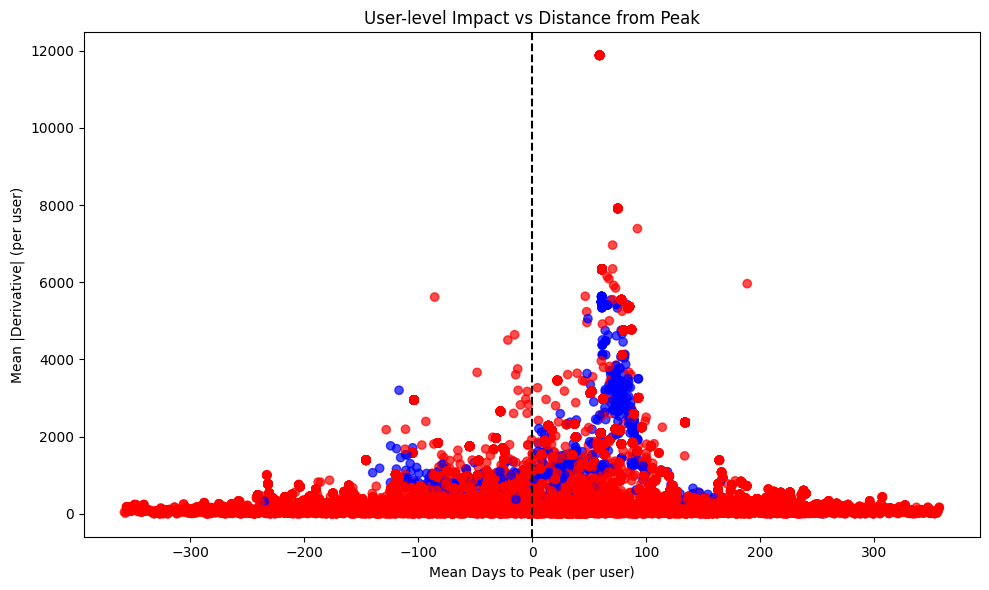

In [82]:
colors = user_df["is_control"].map({True: "red", False: "blue"})

plt.figure(figsize=(10, 6))
plt.scatter(
    user_df["mean_delta_days"],
    user_df["mean_abs_derivative"],
    c=colors,
    alpha=0.7
)

plt.axvline(0, color="black", linestyle="--")

plt.xlabel("Mean Days to Peak (per user)")
plt.ylabel("Mean |Derivative| (per user)")
plt.title("User-level Impact vs Distance from Peak")

plt.tight_layout()
plt.show()


In [85]:
top100_users = (
    user_df
    .sort_values("mean_abs_derivative", ascending=False)
    .head(500)
)
top100_users

,accountid_y,mean_derivative,mean_abs_derivative,mean_delta_days,n_posts,is_control
5797,4563a25bf9d4538851c62915500382a019fd7b8a46,-11881.0,11881.0,59.0,99,True
3592,2b03e84ec85610500ed6ffe63eadabc1dd3d0ea99b,-11881.0,11881.0,59.0,47,True
572,06561a8ee97489da324fb712629882b3f8bf12a17a,-11881.0,11881.0,59.0,99,True
93,01078faac6d96e44adf35c761d1cf60383e7c21feb,-11881.0,11881.0,59.0,42,True
13411,9d24d58a1501283afdfe6996e9dad162a3ea9f4cc7,-11881.0,11881.0,59.0,2,True
...,...,...,...,...,...,...
21274,f8811cacc08fecc692eb49a4a1f1aabd30af80250f,5547.0,5547.0,78.0,4,True
21254,f8447148fdae3cf8a49e07ca0f0b95cbc6feacc426,5547.0,5547.0,78.0,28,True
21248,f82f23d1241bce684b1f78ec77faaeca9faab54463,5547.0,5547.0,78.0,1,True
3596,2b0dbaed099175dd2283f337a3b5a366ea9329e111,5547.0,5547.0,78.0,15,True


In [86]:
top100_users.is_control.value_counts()

,count
is_control,
True,486
False,14


In [60]:
top_abs = post_analysis_df.reindex(
    post_analysis_df["rolling_derivative"].sort_values(ascending=False).index
)

top_abs


,post_id,post_time,derivative,rolling_derivative,peak_relation,nearest_peak,delta_days_to_peak,postid_x,is_control_x,postid_y,accountid,is_control_y
698620,d3ab09c4fc52278234ee378ecacd2439aa4b7f48a5,2018-04-11 00:00:00,6337.0,3801.333333,before_peak,2018-06-11,61,d3ab09c4fc52278234ee378ecacd2439aa4b7f48a5,False,d3ab09c4fc52278234ee378ecacd2439aa4b7f48a5,fc2ac95a517134d73f51ed4c1de0e01f332056d427,False
698621,c45aa1c705fc05e0d55f67e20264f1ff646377fbcd,2018-04-11 00:00:00,6337.0,3801.333333,before_peak,2018-06-11,61,c45aa1c705fc05e0d55f67e20264f1ff646377fbcd,False,c45aa1c705fc05e0d55f67e20264f1ff646377fbcd,43ab37868a531a116d4f31e9bad65687694de149e7,False
698622,e02673ceaace6c2aa6be8d15207dd7b55051dc8be6,2018-04-11 00:00:00,6337.0,3801.333333,before_peak,2018-06-11,61,e02673ceaace6c2aa6be8d15207dd7b55051dc8be6,False,e02673ceaace6c2aa6be8d15207dd7b55051dc8be6,958fb0ccaedf84ffaf46b24682e0eedc8657594e14,False
698623,4ea4bdee56ae4af3db566c52b288739f68623f1425,2018-04-11 00:00:00,6337.0,3801.333333,before_peak,2018-06-11,61,4ea4bdee56ae4af3db566c52b288739f68623f1425,False,4ea4bdee56ae4af3db566c52b288739f68623f1425,51efad7147643cb54f4e4477cbf44120d1086c427b,False
698624,4adcfe6b38e3ab080b93ca9e1c7071f6fdbd3e0d13,2018-04-11 00:00:00,6337.0,3801.333333,before_peak,2018-06-11,61,4adcfe6b38e3ab080b93ca9e1c7071f6fdbd3e0d13,False,4adcfe6b38e3ab080b93ca9e1c7071f6fdbd3e0d13,72964b7eab85ed9a861260775cefe503641db7beee,False
...,...,...,...,...,...,...,...,...,...,...,...,...
723498,ccb907662c9fb85e64f1928e2e60f0a95e0b0f68bb,2018-04-14 00:45:07,-846.0,-4086.333333,before_peak,2018-06-11,58,ccb907662c9fb85e64f1928e2e60f0a95e0b0f68bb,True,ccb907662c9fb85e64f1928e2e60f0a95e0b0f68bb,b3bb73ad61cd756adfc49e9e6a9cde1f6ff8340e13,True
723665,6e569f35efe863440b4f2666340c577ef5d384e845,2018-04-14 22:49:55,-846.0,-4086.333333,before_peak,2018-06-11,58,6e569f35efe863440b4f2666340c577ef5d384e845,True,6e569f35efe863440b4f2666340c577ef5d384e845,c256d2ac1539d84809df8050a080b6ed794af6d6fd,True
723664,d6442c1270e3c401d28bf05b337507a95f647c7e6e,2018-04-14 22:49:35,-846.0,-4086.333333,before_peak,2018-06-11,58,d6442c1270e3c401d28bf05b337507a95f647c7e6e,True,d6442c1270e3c401d28bf05b337507a95f647c7e6e,c256d2ac1539d84809df8050a080b6ed794af6d6fd,True
723663,c638075c68555b374a5e74f106798e73d76e5e7814,2018-04-14 22:49:20,-846.0,-4086.333333,before_peak,2018-06-11,58,c638075c68555b374a5e74f106798e73d76e5e7814,True,c638075c68555b374a5e74f106798e73d76e5e7814,c256d2ac1539d84809df8050a080b6ed794af6d6fd,True


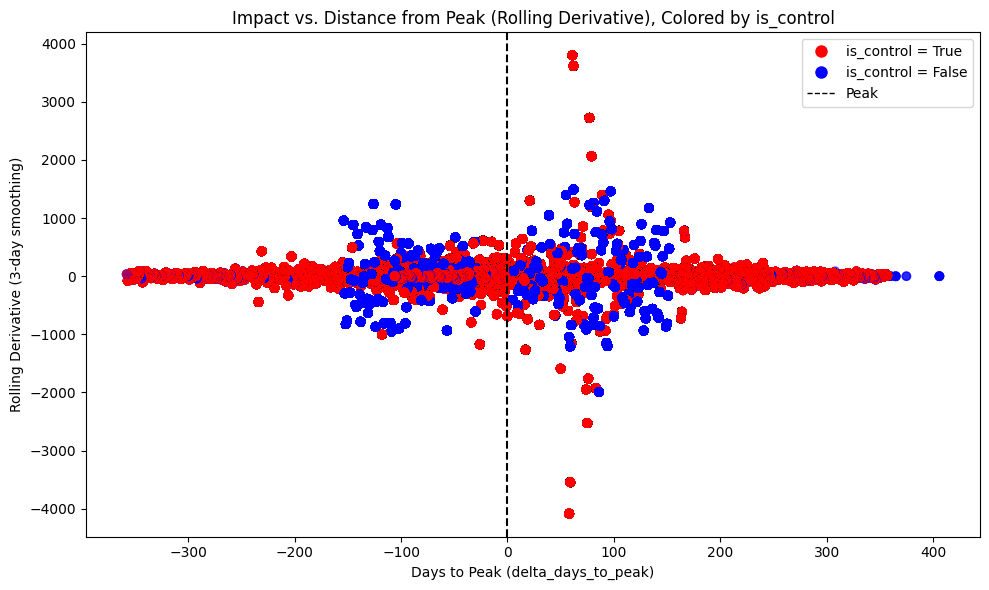

In [62]:
import matplotlib.pyplot as plt

colors = post_analysis_df["is_control_x"].map({True: "red", False: "blue"})

plt.figure(figsize=(10, 6))
plt.scatter(
    post_analysis_df["delta_days_to_peak"],
    post_analysis_df["rolling_derivative"],
    c=colors,
    alpha=0.6
)

plt.axvline(0, color="black", linestyle="--", label="Peak")

plt.xlabel("Days to Peak (delta_days_to_peak)")
plt.ylabel("Rolling Derivative (3-day smoothing)")
plt.title("Impact vs. Distance from Peak (Rolling Derivative), Colored by is_control")

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='is_control = True', markerfacecolor='red', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='is_control = False', markerfacecolor='blue', markersize=10),
    Line2D([0], [0], color='black', lw=1, linestyle='--', label='Peak')
]

plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()


In [63]:
user_df = (
    post_analysis_df
    .groupby("accountid")
    .agg(
        mean_rolling_derivative=("rolling_derivative", "mean"),
        mean_abs_rolling_derivative=("rolling_derivative", lambda x: x.abs().mean()),
        mean_delta_days=("delta_days_to_peak", "mean"),
        n_posts=("post_id", "count"),
        is_control=("is_control_x", "first")
    )
    .reset_index()
)


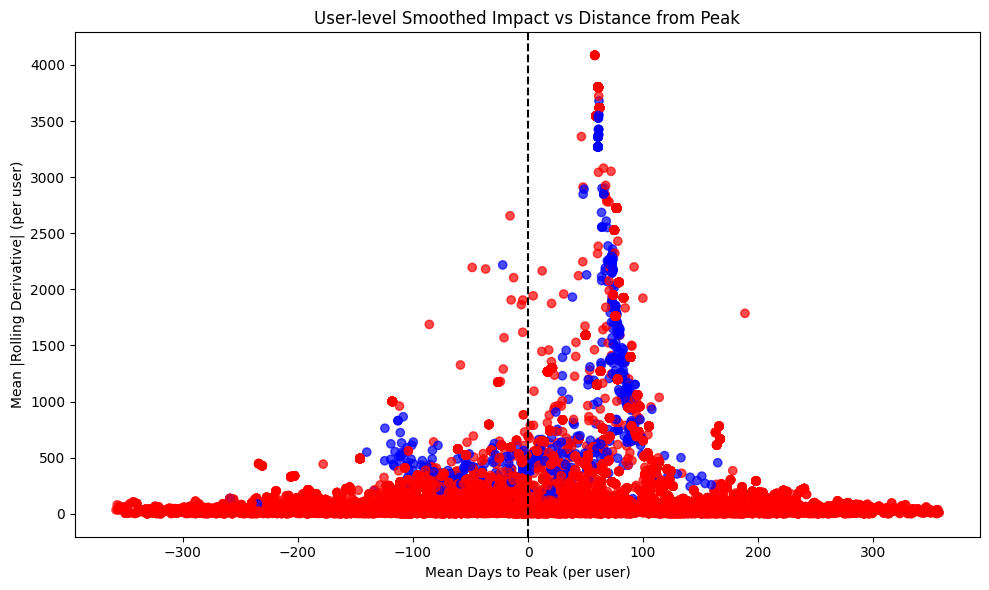

In [64]:
import matplotlib.pyplot as plt

colors = user_df["is_control"].map({True: "red", False: "blue"})

plt.figure(figsize=(10, 6))
plt.scatter(
    user_df["mean_delta_days"],
    user_df["mean_abs_rolling_derivative"],
    c=colors,
    alpha=0.7
)

plt.axvline(0, color="black", linestyle="--")

plt.xlabel("Mean Days to Peak (per user)")
plt.ylabel("Mean |Rolling Derivative| (per user)")
plt.title("User-level Smoothed Impact vs Distance from Peak")

plt.tight_layout()
plt.show()


In [67]:
top100_users = (
    user_df
    .sort_values("mean_abs_rolling_derivative", ascending=False)
    .head(100)
)
top100_users

,accountid,mean_rolling_derivative,mean_abs_rolling_derivative,mean_delta_days,n_posts,is_control
1640,136af1b9f70f3e41ecd59e9edd75437902388bedb6,-4086.333333,4086.333333,58.0,5,True
15674,b73a6140e6503c933929b024ffad2369a8072ee49c,-4086.333333,4086.333333,58.0,4,True
1351,0fd338107210dad6b6fac96fcb93fa157bdcae7837,-4086.333333,4086.333333,58.0,4,True
16621,c256d2ac1539d84809df8050a080b6ed794af6d6fd,-4086.333333,4086.333333,58.0,99,True
15375,b3bb73ad61cd756adfc49e9e6a9cde1f6ff8340e13,-4086.333333,4086.333333,58.0,91,True
...,...,...,...,...,...,...
15208,b209b974cb1d573f4807e3aa3092fc6fe96e089074,3801.333333,3801.333333,61.0,19,True
6275,4a8932fd02c2c6e2a9afab2fc959ed66194485927c,3801.333333,3801.333333,61.0,70,True
14999,af8461b93e36ce7f1d4979902bfaff13b2250ddac0,3801.333333,3801.333333,61.0,1,True
4936,3b71c72518bef624ffebf74b02e9fe65e65eeca983,3801.333333,3801.333333,61.0,5,True


In [68]:
top100_users.is_control.value_counts()

,count
is_control,
True,98
False,2


#create pipeline boost

In [91]:
import pandas as pd
import numpy as np


df["post_time"] = pd.to_datetime(df["post_time"], errors="coerce")
df = df.dropna(subset=["post_time"])


##HASHTAG Boost

In [92]:
hashtags_df = df[["post_time", "hashtags"]].explode("hashtags")
hashtags_df = hashtags_df.dropna(subset=["hashtags"])


In [93]:
hashtag_ts = (
    hashtags_df
    .groupby([hashtags_df["post_time"].dt.date, "hashtags"])
    .size()
    .rename("count")
    .reset_index()
)


In [94]:
hashtag_ts

,post_time,hashtags,count
0,2010-06-14,#spa,3
1,2010-06-14,SPA,1
2,2010-06-14,ita,2
3,2010-06-14,mundialenpausa,1
4,2010-06-14,par,1
...,...,...,...
358015,2019-07-30,JuegosPanamericanosEc,2
358016,2019-07-30,LaTrataEsUnDelito,11
358017,2019-07-30,SomosEducaciónEC,2
358018,2019-07-30,SoyBachiller,1


In [95]:
def compute_entity_boost(ts_df, entity_col, window=3):
    results = []

    for entity, g in ts_df.groupby(entity_col):
        g = g.sort_values("post_time")
        g["smoothed"] = g["count"].rolling(window, center=True).mean()
        g["boost"] = g["smoothed"].diff().fillna(0)

        g["entity"] = entity
        results.append(g)

    return pd.concat(results, ignore_index=True)


In [96]:
hashtag_boost_df = compute_entity_boost(
    hashtag_ts.rename(columns={"hashtags": "entity"}),
    entity_col="entity"
)


##ACCOUNT MENTIONS Boost

In [97]:
mentions_df = df[["post_time", "account_mentions"]].explode("account_mentions")
mentions_df = mentions_df.dropna(subset=["account_mentions"])


In [98]:
mentions_ts = (
    mentions_df
    .groupby([mentions_df["post_time"].dt.date, "account_mentions"])
    .size()
    .rename("count")
    .reset_index()
)


In [99]:
mention_boost_df = compute_entity_boost(
    mentions_ts.rename(columns={"account_mentions": "entity"}),
    entity_col="entity"
)


In [100]:
def get_post_entity_boost(post_row, entity_boost_df, agg="max"):
    boosts = []

    post_date = post_row["post_time"].date()

    for h in post_row["hashtags"]:
        val = entity_boost_df.query(
            "entity == @h and entity_type == 'hashtag' and post_time == @post_date"
        )
        if not val.empty:
            boosts.append(val["boost"].iloc[0])

    for m in post_row["account_mentions"]:
        val = entity_boost_df.query(
            "entity == @m and entity_type == 'account_mention' and post_time == @post_date"
        )
        if not val.empty:
            boosts.append(val["boost"].iloc[0])

    if not boosts:
        return 0

    return max(boosts) if agg == "max" else np.mean(boosts)


In [101]:
entity_boost_df = pd.concat(
    [
        hashtag_boost_df.assign(entity_type="hashtag"),
        mention_boost_df.assign(entity_type="account_mention")
    ],
    ignore_index=True
)


In [102]:
entity_boost_df

,post_time,entity,count,smoothed,boost,entity_type
0,2010-09-26,#26S,2,NaN,0.000000,hashtag
1,2010-12-03,#Bestupid,1,NaN,0.000000,hashtag
2,2010-12-09,#Chao,1,NaN,0.000000,hashtag
3,2010-11-22,#Confieso,1,NaN,0.000000,hashtag
4,2010-12-31,#CosasQueMe,1,NaN,0.000000,hashtag
...,...,...,...,...,...,...
1004909,2017-04-19,ffffd0e61400011a65183c78be777f4265c13efd9c,2,NaN,0.000000,account_mention
1004910,2017-10-30,ffffd0e61400011a65183c78be777f4265c13efd9c,1,1.666667,0.000000,account_mention
1004911,2018-02-15,ffffd0e61400011a65183c78be777f4265c13efd9c,2,2.000000,0.333333,account_mention
1004912,2018-04-11,ffffd0e61400011a65183c78be777f4265c13efd9c,3,NaN,0.000000,account_mention


In [105]:
import pandas as pd
import numpy as np

df["post_time"] = pd.to_datetime(df["post_time"])
df["post_date"] = df["post_time"].dt.date

def extract_entities(row):
    entities = []
    for h in row["hashtags"]:
        entities.append((h.lower(), "hashtag"))
    for m in row["account_mentions"]:
        entities.append((m.lower(), "mention"))
    return entities

df["entities"] = df.apply(extract_entities, axis=1)


In [110]:
df = df.copy()
df["post_time"] = pd.to_datetime(df["post_time"])
df["post_date"] = df["post_time"].dt.date

rows = []

for _, row in df.iterrows():
    for h in row["hashtags"]:
        rows.append({
            "postid": row["postid"],
            "post_date": row["post_date"],
            "accountid": row["accountid"],
            "is_control": row["is_control"],
            "entity": h.lower(),
            "entity_type": "hashtag"
        })
    for m in row["account_mentions"]:
        rows.append({
            "postid": row["postid"],
            "post_date": row["post_date"],
            "accountid": row["accountid"],
            "is_control": row["is_control"],
            "entity": m.lower(),
            "entity_type": "mention"
        })

post_entities_df = pd.DataFrame(rows)


In [114]:
entity_boost_df = entity_boost_df.reset_index()


In [120]:
entity_boost_df = entity_boost_df.copy()

entity_boost_df["post_time"] = pd.to_datetime(entity_boost_df["post_time"])
entity_boost_df["post_date"] = entity_boost_df["post_time"].dt.date


In [121]:
entity_boost_df["entity"] = entity_boost_df["entity"].str.lower()

merged = post_entities_df.merge(
    entity_boost_df,
    on=["post_date", "entity", "entity_type"],
    how="left"
)


In [127]:
def compute_post_boost(merged_df, agg_func="max"):
    """
    Compute post-level boost by aggregating entity-level boosts per post.

    Parameters
    ----------
    merged_df : pd.DataFrame
        Output of post-entity merge, including 'boost'.
    agg_func : str
        Aggregation function: 'max' or 'mean'.

    Returns
    -------
    pd.DataFrame
        post_boost_df with one row per post.
    """
    return (
        merged_df
        .groupby(["postid", "accountid", "is_control", "post_date"])
        .boost
        .agg(agg_func)
        .fillna(0)
        .reset_index()
    )


In [129]:
def compute_daily_boost(post_boost_df, agg_func="mean"):
    """
    Aggregate post-level boost to daily level.

    Parameters
    ----------
    post_boost_df : pd.DataFrame
        Output of compute_post_boost.
    agg_func : str
        Aggregation function: 'mean' or 'max'.

    Returns
    -------
    pd.DataFrame
        daily_boost_df
    """
    return (
        post_boost_df
        .groupby(["post_date", "is_control"])
        .boost
        .agg(agg_func)
        .reset_index()
    )


In [131]:
import matplotlib.pyplot as plt

def plot_boost_over_time(daily_boost_df):
    plt.figure(figsize=(12, 6))
    for is_control, grp in daily_boost_df.groupby("is_control"):
        label = "Control" if is_control else "IO"
        plt.plot(grp["post_date"], grp["boost"], label=label)

    plt.xlabel("Date")
    plt.ylabel("Boost")
    plt.title("Post Boost Over Time (IO vs Control)")
    plt.legend()
    plt.tight_layout()
    plt.show()


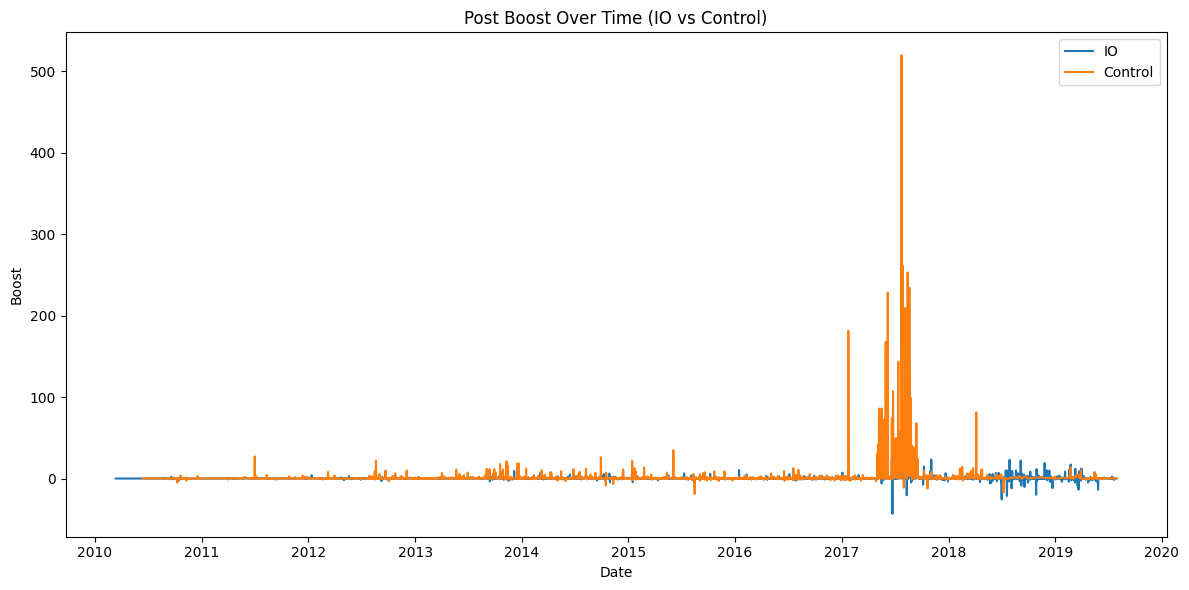

In [132]:
post_boost_df = compute_post_boost(merged, agg_func="max")
daily_boost = compute_daily_boost(post_boost_df, agg_func="mean")
plot_boost_over_time(daily_boost)


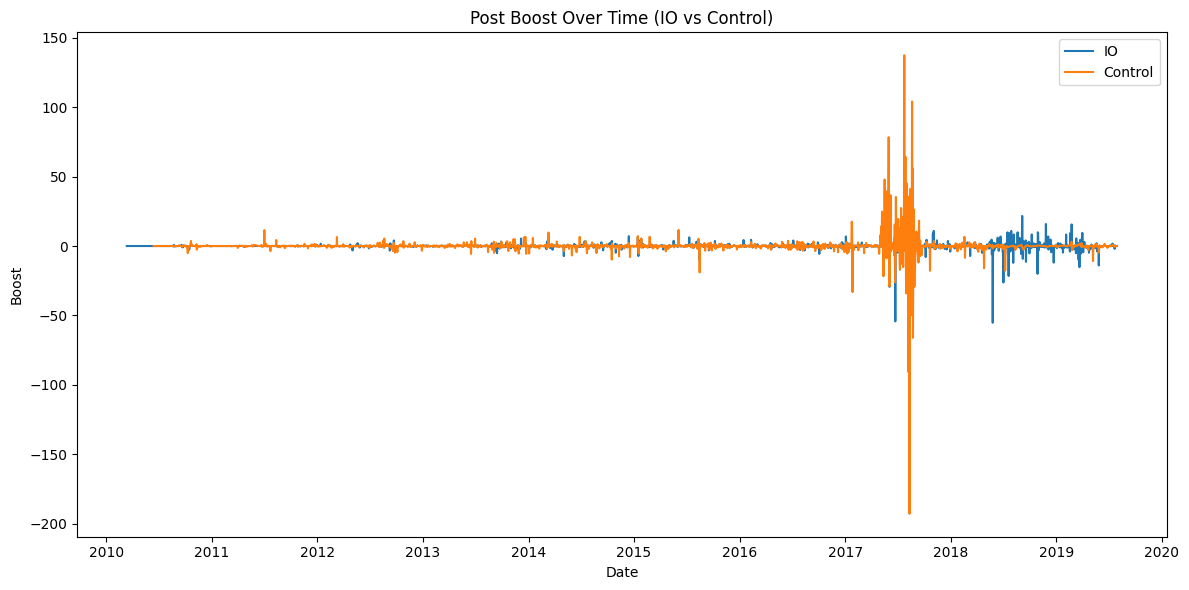

In [133]:
post_boost_df = compute_post_boost(merged, agg_func="mean")
daily_boost = compute_daily_boost(post_boost_df, agg_func="mean")
plot_boost_over_time(daily_boost)
